 #  Documentación del Dataset: Simulación de Consumo Energético

## 1. Descripción General
Este pipeline de generación de datos crea un conjunto de datos sintético y realista diseñado específicamente para tareas de Análisis Exploratorio de Datos (EDA) y entrenamiento de modelos de Machine Learning (Clasificación Multiclase).

El script simula el comportamiento energético de miles de viviendas, basándose en características estructurales, demográficas, de equipamiento y factores climáticos. Además, incluye un módulo de inyección de imperfecciones controladas para habilitar la práctica de *Data Cleaning* y manejo de valores atípicos (*Outliers*).

## 2. Especificaciones Técnicas
*   **Volumen Base:** 10,000 registros únicos.
*   **Volumen Final:** ~10,100 registros (incluye un 1% de duplicados estructurales inyectados).
*   **Variable Objetivo (*Target*):** `categoria` (Eficiencia Energética: *Efficient, Moderate, Inefficient*).
*   **Reproducibilidad:** Semilla aleatoria (SEED) fijada en `42` para garantizar que los resultados sean consistentes en cada ejecución.

---

## 3. Lógica de Simulación Estadística
Para garantizar el realismo de los datos y evitar distribuciones uniformes planas, se aplicaron las siguientes reglas matemáticas:
*   **Distribuciones Log-normales:** Utilizadas para los `metros_cuadrados` y el `ingreso_mensual`, simulando la realidad económica donde la mayoría se concentra en valores medios-bajos, con una "cola larga" de propiedades/ingresos de gran magnitud.
*   **Distribución de Poisson:** Empleada para variables de conteo discreto (ej. `habitaciones`, `aires_acondicionados`, `cantidad_personas`), asegurando que no existan valores negativos y respetando proporciones lógicas (ej. 1 habitación por cada ~35m²).
*   **Asociación de Variables:** El ecosistema de datos está fuertemente correlacionado. Por ejemplo, una casa antigua tiene mayor probabilidad de tener un mal aislamiento térmico, y los ingresos mensuales condicionan la cantidad de electrodomésticos.

---

## 4. Diccionario de Datos

A continuación, se detallan las variables generadas, agrupadas por su módulo de origen:

###  Características de la Vivienda (`crear_viviendas`)
*   **`id`** (Entero): Identificador único del registro.
*   **`tipo_vivienda`** (Categórica): Clasificación del inmueble ('Casa', 'Departamento', 'Pequeño Comercio').
*   **`metros_cuadrados`** (Flotante): Superficie del inmueble acotada entre 30m² y 450m².
*   **`habitaciones`** (Entero): Cantidad de habitaciones (condicionado por los metros cuadrados).
*   **`baños`** (Entero): Cantidad de baños (condicionado por las habitaciones).
*   **`antiguedad_vivienda`** (Entero): Años de antigüedad del inmueble (Distribución triangular, moda = 15).
*   **`aislamiento`** (Categórica): Calidad del aislamiento térmico ('Poor', 'Average', 'Good', 'Excellent').
*   **`eficiencia_construccion`** (Categórica): Calificación constructiva ('E', 'D', 'C', 'B', 'A').
*   **`paneles_solares`** (Booleano): Indica si la propiedad posee generación solar.

###  Demografía y Ocupación (`crear_habitantes`)
*   **`cantidad_personas`** (Entero): Habitantes de la propiedad (relacionado con el número de habitaciones).
*   **`trabajo_remoto`** (Booleano): Indica si al menos un habitante hace *Home Office*.
*   **`horas_en_casa`** (Flotante): Promedio de horas diarias de ocupación de la vivienda.
*   **`ingreso_mensual`** (Flotante): Ingreso estimado del hogar en USD (correlacionado con el tamaño del inmueble).

###  Equipamiento y Climatización (`crear_equipamiento`)
*   **`aires_acondicionados`** (Entero): Cantidad de equipos de aire acondicionado (0 a 5).
*   **`heladeras`** (Entero): Conteo de heladeras/refrigeradores.
*   **`televisores`** (Entero): Conteo de televisores en la vivienda.
*   **`computadoras`** (Entero): Conteo de computadoras personales o de escritorio.
*   **`lavadoras`** (Entero): Conteo de máquinas lavadoras.
*   **`secadoras`** (Entero): Conteo de máquinas secadoras de ropa.
*   **`cantidad_equipos`** (Entero): Suma total de dispositivos eléctricos, incluyendo pequeños electrodomésticos.
*   **`calefaccion`** (Booleano): Existencia de sistema térmico de invierno.
*   **`tipo_calefaccion`** (Categórica): Tipo de sistema térmico de invierno ('Ninguna', 'Gas', 'Losa Radiante', 'Eléctrica').
*   **`tipo_iluminacion`** (Categórica): Tecnología de iluminación predominante ('LED', 'Mixta', 'Incandescente').
*   **`electrodomesticos_eficientes`** (Flotante): Porcentaje del parque de electrodomésticos considerado de alta eficiencia (%).

###  Consumo Energético (`crear_consumo`)
*   **`factor_estacional`** (Categórica): Estación del año en la que se registra la medición ('Verano', 'Invierno', etc.).
*   **`temperatura_media`** (Flotante): Temperatura climática asignada según la estación (con ruido estocástico).
*   **`consumo_kwh`** (Flotante): **Variable principal de análisis:** Consumo total simulado en kilovatios-hora.
*   **`uso_horario_pico`** (Booleano): Indica si el mayor consumo se da en franjas de alta demanda.
*   **`horas_alto_consumo`** (Entero): Franja horaria de mayor demanda eléctrica de la propiedad.
*   **`tarifa_kwh`** (Flotante): Precio variable del kWh en USD.
*   **`costo_estimado`** (Flotante): Facturación estimada (Consumo multiplicado por Tarifa). *Nota: Altamente correlacionada con el consumo.*

###  Puntuación y Variable Objetivo (`crear_score_y_target`)
*   **`energy_efficiency_score`** (Flotante): Puntuación determinística (0-100) basada en la eficiencia de la infraestructura y el consumo per cápita.
*   **`categoria`** (Categórica): **Variable Target (Clasificación):** Etiqueta de eficiencia ('Efficient', 'Moderate', 'Inefficient'). Asignada por percentiles.

---

## 5. Diseño de Imperfecciones Inyectadas (Data Cleaning)
Para enriquecer el proceso de Ingeniería de Datos, el módulo `inyectar_imperfecciones` aplica ruido intencional al dataset base:
1.  **Valores Nulos (NaN):** Inyectados de forma aleatoria (MCAR - *Missing Completely At Random*) entre un 2% y 6% en columnas clave como `ingreso_mensual`, `antiguedad_vivienda`, `electrodomesticos_eficientes` y `horas_en_casa`.
2.  **Outliers Extremos (Mansiones):** Simulación de propiedades inusualmente grandes, modificando el 0.5% de los datos con superficies entre 500m² y 1200m².
3.  **Outliers Extremos (Anomalías Energéticas):** Simulación de consumos absurdos (ej. Minería Cripto clandestina), multiplicando aleatoriamente el consumo de algunas viviendas por factores de 4 a 8.
4.  **Inconsistencias Lógicas:** Creación de registros contradictorios, como propiedades con excelente aislamiento y paneles solares, pero con un consumo inexplicablemente altísimo, requiriendo investigación en el EDA.
5.  **Registros Duplicados:** 1% del dataset copiado de manera idéntica y con reasignación de ID para forzar una limpieza basada en el análisis de características estructurales repetidas.

In [ ]:
import pandas as pd
import numpy as np
import random
from pathlib import Path
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# CONFIGURACIÓN GLOBAL
# ==========================================
SEED = 42
N_REGISTROS = 10000

np.random.seed(SEED)
random.seed(SEED)

# ==========================================
# MÓDULOS DE GENERACIÓN DE DATOS
# ==========================================

def crear_viviendas(n: int) -> pd.DataFrame:
    """
    Genera las características estructurales de las viviendas.
    Utiliza distribuciones log-normales para áreas (evitando colas largas irreales)
    y poisson para conteo de habitaciones.
    """
    df = pd.DataFrame({'id': range(1, n + 1)})

    # 1. Tipo de vivienda (Distribución categórica)
    df['tipo_vivienda'] = np.random.choice(
        ['Casa', 'Departamento', 'Pequeño Comercio'],
        size=n, p=[0.55, 0.40, 0.05]
    )

    # 2. Metros Cuadrados (Log-normal acotada por tipo)
    def generar_m2(tipo):
        if tipo == 'Casa':
            return np.random.lognormal(mean=np.log(120), sigma=0.4)
        elif tipo == 'Departamento':
            return np.random.lognormal(mean=np.log(65), sigma=0.3)
        else:
            return np.random.lognormal(mean=np.log(90), sigma=0.5)

    df['metros_cuadrados'] = df['tipo_vivienda'].apply(generar_m2)
    df['metros_cuadrados'] = np.clip(df['metros_cuadrados'], 30, 450).round(1)

    # 3. Habitaciones y Baños (Poisson correlacionado al tamaño)
    # 1 habitación por cada ~35m2 + base
    lambda_hab = df['metros_cuadrados'] / 35
    df['habitaciones'] = np.random.poisson(lam=lambda_hab)
    df['habitaciones'] = np.clip(df['habitaciones'], 1, 8).astype(int)

    # 1 baño por cada 2-3 habitaciones
    df['baños'] = np.random.poisson(lam=(df['habitaciones'] / 2 + 0.5))
    df['baños'] = np.clip(df['baños'], 1, 5).astype(int)

    # 4. Antigüedad (Distribución Triangular, la mayoría tiene ~15 años)
    df['antiguedad_vivienda'] = np.random.triangular(left=0, mode=15, right=80, size=n).astype(int)

    # 5. Aislamiento y Eficiencia (Correlacionado inversamente con antigüedad)
    # Viviendas más nuevas tienden a tener mejor aislamiento
    prob_base = np.clip(1 - (df['antiguedad_vivienda'] / 80), 0.1, 0.9)

    aislamiento_choices = ['Poor', 'Average', 'Good', 'Excellent']
    df['aislamiento'] = [
        np.random.choice(aislamiento_choices, p=[1-p, (1-p)*0.5, p*0.6, p*0.4] / np.sum([1-p, (1-p)*0.5, p*0.6, p*0.4]))
        for p in prob_base
    ]

    eficiencia_choices = ['E', 'D', 'C', 'B', 'A']
    df['eficiencia_construccion'] = [
        np.random.choice(eficiencia_choices, p=[1-p, (1-p)*0.5, 0.2, p*0.5, p*0.5] / np.sum([1-p, (1-p)*0.5, 0.2, p*0.5, p*0.5]))
        for p in prob_base
    ]

    # 6. Paneles Solares (Binomial: Mayor probabilidad en casas nuevas y grandes)
    prob_solar = np.where(df['tipo_vivienda'] == 'Casa', 0.08, 0.01)
    prob_solar += np.where(df['antiguedad_vivienda'] < 10, 0.05, 0.0)
    df['paneles_solares'] = np.random.binomial(1, np.clip(prob_solar, 0.0, 0.2)).astype(bool)

    return df

def crear_habitantes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera información demográfica y ocupacional fuertemente atada
    a las características del inmueble.
    """
    n = len(df)

    # 1. Cantidad de personas (Poisson condicionado por habitaciones)
    lambda_personas = np.where(df['tipo_vivienda'] == 'Pequeño Comercio',
                               df['habitaciones'] * 1.5,
                               df['habitaciones'] * 0.8 + 0.5)
    df['cantidad_personas'] = np.random.poisson(lam=lambda_personas)
    df['cantidad_personas'] = np.clip(df['cantidad_personas'], 1, 8).astype(int)

    # 2. Trabajo Remoto (Binomial)
    # Comercitos no tienen "trabajo remoto" per se en este contexto
    prob_remoto = np.where(df['tipo_vivienda'] == 'Pequeño Comercio', 0.0, 0.35)
    df['trabajo_remoto'] = np.random.binomial(1, prob_remoto).astype(bool)

    # 3. Horas en casa (Distribución normal ajustada por remoto/tipo)
    base_horas = np.random.normal(loc=12, scale=3, size=n)
    horas = np.where(df['trabajo_remoto'], base_horas + 8, base_horas)
    df['horas_en_casa'] = np.clip(horas, 8, 24).round(1)

    # 4. Ingreso Mensual (Distribución Log-normal, correlacionado con m2 y personas)
    # Simulamos valores en dólares (USD) para estandarización.
    base_ingreso = np.random.lognormal(mean=np.log(1500), sigma=0.6, size=n)
    multiplicador_m2 = df['metros_cuadrados'] / df['metros_cuadrados'].mean()
    df['ingreso_mensual'] = (base_ingreso * multiplicador_m2).round(2)

    return df

def crear_equipamiento(df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera el parque de electrodomésticos basándose en poder adquisitivo,
    tamaño del inmueble y cantidad de habitantes.
    """
    n = len(df)

    # Aires acondicionados (Correlación con m2 e ingresos)
    prob_ac = (df['metros_cuadrados'] / 100) * (df['ingreso_mensual'] / 2000)
    df['aires_acondicionados'] = np.random.poisson(lam=np.clip(prob_ac, 0.5, 3))
    df['aires_acondicionados'] = np.clip(df['aires_acondicionados'], 0, 5).astype(int)

    # Heladeras (Al menos 1, más si hay mucha gente/comercios)
    df['heladeras'] = 1 + np.random.binomial(1, p=np.clip(df['cantidad_personas']/10, 0, 0.5))
    df['heladeras'] = np.where(df['tipo_vivienda'] == 'Pequeño Comercio', df['heladeras'] + 1, df['heladeras'])

    # Computadoras y TVs
    df['televisores'] = np.random.poisson(lam=df['cantidad_personas'] * 0.7)
    df['computadoras'] = np.random.poisson(lam=df['cantidad_personas'] * 0.8)
    df['computadoras'] = np.where(df['trabajo_remoto'], df['computadoras'] + 1, df['computadoras'])

    # Lavado
    df['lavadoras'] = np.where(df['tipo_vivienda'] != 'Pequeño Comercio', 1, 0)
    df['secadoras'] = np.random.binomial(1, p=np.clip(df['ingreso_mensual']/10000, 0.05, 0.4))

    df['cantidad_equipos'] = (df['aires_acondicionados'] + df['heladeras'] +
                              df['televisores'] + df['computadoras'] +
                              df['lavadoras'] + df['secadoras'] +
                              np.random.poisson(lam=5, size=n)) # Pequeños electrodomésticos

    # Calefacción y climatización
    df['calefaccion'] = np.random.choice([True, False], size=n, p=[0.8, 0.2])

    def asignar_tipo_calefaccion(row):
        if not row['calefaccion']: return 'Ninguna'
        if row['antiguedad_vivienda'] > 30: return 'Gas'
        if row['ingreso_mensual'] > 4000: return 'Losa Radiante'
        return 'Eléctrica'

    df['tipo_calefaccion'] = df.apply(asignar_tipo_calefaccion, axis=1)

    # Iluminación
    df['tipo_iluminacion'] = np.where(
        df['antiguedad_vivienda'] < 10,
        np.random.choice(['LED', 'Mixta'], size=n, p=[0.8, 0.2]),
        np.random.choice(['LED', 'Mixta', 'Incandescente'], size=n, p=[0.3, 0.5, 0.2])
    )

    # Eficiencia de electrodomésticos (%)
    # Normal distribution, negatively correlated with home age.
    base_eff = 80 - (df['antiguedad_vivienda'] * 0.5) + (df['ingreso_mensual'] / 1000)
    df['electrodomesticos_eficientes'] = np.random.normal(loc=base_eff, scale=10)
    df['electrodomesticos_eficientes'] = np.clip(df['electrodomesticos_eficientes'], 10, 100).round(1)

    return df

def crear_consumo(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula el consumo eléctrico basándose en las variables anteriores,
    aplicando ruido estocástico (Gaussian noise) para realismo.
    """
    n = len(df)

    # Estacionalidad
    estaciones = ['Verano', 'Invierno', 'Primavera', 'Otoño']
    df['factor_estacional'] = np.random.choice(estaciones, size=n)

    # Temperatura Media (Dependiente de la estación + ruido)
    temp_dict = {'Verano': 28, 'Invierno': 8, 'Primavera': 20, 'Otoño': 15}
    df['temperatura_media'] = df['factor_estacional'].map(temp_dict) + np.random.normal(0, 3, size=n)
    df['temperatura_media'] = df['temperatura_media'].round(1)

    # Consumo Base Físico
    consumo_base = (df['metros_cuadrados'] * 0.8) + (df['cantidad_personas'] * 45)

    # Consumo de Climatización (Penalizado por mal aislamiento)
    factor_aislamiento = df['aislamiento'].map({'Poor': 1.4, 'Average': 1.1, 'Good': 0.8, 'Excellent': 0.6})

    consumo_frio = np.where((df['factor_estacional'] == 'Verano') & (df['aires_acondicionados'] > 0),
                            df['aires_acondicionados'] * 120 * factor_aislamiento, 0)

    consumo_calor = np.where((df['factor_estacional'] == 'Invierno') & (df['tipo_calefaccion'] == 'Eléctrica'),
                             180 * factor_aislamiento, 0)

    # Consumo Equipamiento
    factor_iluminacion = df['tipo_iluminacion'].map({'LED': 0.6, 'Mixta': 1.0, 'Incandescente': 1.8})
    consumo_equipos = (df['cantidad_equipos'] * 25) * factor_iluminacion * (1 - (df['electrodomesticos_eficientes'] * 0.003))

    # Suma de consumos + Impacto de horas en casa
    consumo_total = (consumo_base + consumo_frio + consumo_calor + consumo_equipos) * (df['horas_en_casa'] / 16)

    # Descuento por paneles solares (Reduce entre 20% y 60% del consumo de red)
    descuento_solar = np.where(df['paneles_solares'], np.random.uniform(0.2, 0.6, size=n), 0)
    consumo_total = consumo_total * (1 - descuento_solar)

    # Ruido Aleatorio (Añade imperfección humana)
    ruido = np.random.normal(1.0, 0.15, size=n)
    df['consumo_kwh'] = np.clip(consumo_total * ruido, 50, None).round(2)

    # Variables de Uso
    df['uso_horario_pico'] = np.where(df['trabajo_remoto'],
                                      np.random.binomial(1, 0.7),
                                      np.random.binomial(1, 0.4)).astype(bool)

    df['horas_alto_consumo'] = np.where(df['uso_horario_pico'],
                                        np.random.normal(19, 2, size=n),
                                        np.random.normal(14, 4, size=n))
    df['horas_alto_consumo'] = np.clip(df['horas_alto_consumo'], 0, 23).astype(int)

    # Variables Económicas
    df['tarifa_kwh'] = np.random.normal(0.18, 0.02, size=n).round(3) # Precio en USD/kWh con variaciones
    df['costo_estimado'] = (df['consumo_kwh'] * df['tarifa_kwh']).round(2)

    return df

def crear_score_y_target(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula un "Energy Efficiency Score" transparente y determinístico,
    y a partir de ahí asigna la variable objetivo desbalanceada.
    """
    # Índices parciales (Max ~ 100)
    idx_aislamiento = df['aislamiento'].map({'Poor': 0, 'Average': 10, 'Good': 20, 'Excellent': 30})
    idx_const = df['eficiencia_construccion'].map({'E': 0, 'D': 5, 'C': 10, 'B': 15, 'A': 20})
    idx_paneles = np.where(df['paneles_solares'], 15, 0)
    idx_electro = (df['electrodomesticos_eficientes'] / 100) * 20
    idx_ilum = df['tipo_iluminacion'].map({'Incandescente': 0, 'Mixta': 7, 'LED': 15})

    # Penalización por consumo excesivo per cápita
    consumo_per_capita = df['consumo_kwh'] / df['cantidad_personas']
    penalizacion = np.clip((consumo_per_capita - 150) / 10, 0, 30)

    score_crudo = idx_aislamiento + idx_const + idx_paneles + idx_electro + idx_ilum - penalizacion

    # Añadir un leve ruido al score (para que el modelo ML tenga que esforzarse)
    score_final = score_crudo + np.random.normal(0, 5, size=len(df))
    df['energy_efficiency_score'] = np.clip(score_final, 0, 100).round(1)

    # Target: Asignación por percentiles para forzar el desbalance deseado (~30% / 45% / 25%)
    p70 = np.percentile(df['energy_efficiency_score'], 70) # Top 30%
    p25 = np.percentile(df['energy_efficiency_score'], 25) # Bottom 25%

    def clasificar(score):
        if score >= p70: return 'Efficient'
        elif score <= p25: return 'Inefficient'
        else: return 'Moderate'

    df['categoria'] = df['energy_efficiency_score'].apply(clasificar)

    return df

def inyectar_imperfecciones(df: pd.DataFrame) -> pd.DataFrame:
    """
    Inyecta ruido sucio, missing values (NaN), outliers e inconsistencias
    necesarias para la fase de Data Cleaning y EDA.
    """
    df_dirty = df.copy()
    n = len(df_dirty)

    # 1. Valores Faltantes (MCAR - Missing Completely At Random)
    cols_na = ['ingreso_mensual', 'antiguedad_vivienda', 'electrodomesticos_eficientes', 'horas_en_casa']
    for col in cols_na:
        prop_na = np.random.uniform(0.02, 0.06)
        mask = np.random.choice([True, False], size=n, p=[prop_na, 1 - prop_na])
        df_dirty.loc[mask, col] = np.nan

    # 2. Outliers (Casos extremos pero plausibles)
    # Mansiones enormes
    idx_out_m2 = np.random.choice(df_dirty.index, size=int(n * 0.005), replace=False)
    df_dirty.loc[idx_out_m2, 'metros_cuadrados'] = np.random.uniform(500, 1200, size=len(idx_out_m2))

    # Granjas de servidores / Minería cripto escondida (Consumo absurdo)
    idx_out_cons = np.random.choice(df_dirty.index, size=int(n * 0.005), replace=False)
    df_dirty.loc[idx_out_cons, 'consumo_kwh'] = df_dirty.loc[idx_out_cons, 'consumo_kwh'] * np.random.uniform(4, 8)

    # 3. Inconsistencias Lógicas Controladas
    # Casas 'Excellent' pero que consumen excesivamente
    idx_inc = np.random.choice(df_dirty[(df_dirty['aislamiento'] == 'Excellent') &
                                        (df_dirty['paneles_solares'] == True)].index,
                               size=int(n * 0.002), replace=False)
    df_dirty.loc[idx_inc, 'consumo_kwh'] = np.random.uniform(2000, 3500, size=len(idx_inc))

    # 4. Duplicados
    num_duplicados = int(n * 0.01)
    df_duplicados = df_dirty.sample(n=num_duplicados, random_state=SEED)
    df_dirty = pd.concat([df_dirty, df_duplicados]).reset_index(drop=True)

    # Mezclamos el dataset (Shuffle)
    df_dirty = df_dirty.sample(frac=1, random_state=SEED).reset_index(drop=True)
    df_dirty['id'] = range(1, len(df_dirty) + 1) # Rehacer IDs para no delatar los duplicados fácilmente

    return df_dirty

def main():
    print(f"🚀 Iniciando generación de dataset de Consumo Energético ({N_REGISTROS} registros)...")

    # Ejecutar pipeline
    df = crear_viviendas(N_REGISTROS)
    df = crear_habitantes(df)
    df = crear_equipamiento(df)
    df = crear_consumo(df)
    df = crear_score_y_target(df)
    df_final = inyectar_imperfecciones(df)

    # Exportar a CSV
    filename = 'dataset_consumo_energetico.csv'
    df_final.to_csv(filename, index=False, encoding='utf-8')

    # ==========================================
    # REPORTING Y ESTADÍSTICAS
    # ==========================================
    print(f"\n✅ Dataset generado y guardado como: '{filename}'")
    print("-" * 50)
    print("📊 RESUMEN DE LOS DATOS GENERADOS")
    print("-" * 50)
    print(f"🔹 Número total de registros (con duplicados): {len(df_final)}")
    print(f"🔹 Número de columnas: {df_final.shape[1]}")
    print(f"🔹 Duplicados intencionales agregados: {len(df_final) - N_REGISTROS}")
    print("\n⚠️ Valores faltantes inyectados por columna:")
    missing = df_final.isnull().sum()
    print(missing[missing > 0].to_string())

    print("\n🎯 Distribución de la Variable Objetivo (Categoría):")
    print(df_final['categoria'].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %')

    print("\n💰 Estadísticas Descriptivas (Muestra reducida):")
    cols_desc = ['metros_cuadrados', 'cantidad_personas', 'consumo_kwh', 'costo_estimado']
    print(df_final[cols_desc].describe().round(2))

    print("\n🔗 Matriz de Correlación (Top variables numéricas):")
    cols_corr = ['metros_cuadrados', 'habitaciones', 'aires_acondicionados', 'consumo_kwh', 'energy_efficiency_score']
    print(df_final[cols_corr].corr().round(3))

    print("-" * 50)
    print("¡Listo! Tienes un dataset con distribuciones reales, correlaciones latentes, ruido estadístico y data sucia lista para EDA y Machine Learning.")

if __name__ == '__main__':
    main()

🚀 Iniciando generación de dataset de Consumo Energético (10000 registros)...

✅ Dataset generado y guardado como: 'dataset_consumo_energetico.csv'
--------------------------------------------------
📊 RESUMEN DE LOS DATOS GENERADOS
--------------------------------------------------
🔹 Número total de registros (con duplicados): 10100
🔹 Número de columnas: 33
🔹 Duplicados intencionales agregados: 100

⚠️ Valores faltantes inyectados por columna:
antiguedad_vivienda             461
horas_en_casa                   289
ingreso_mensual                 438
electrodomesticos_eficientes    278

🎯 Distribución de la Variable Objetivo (Categoría):
categoria
Moderate       44.92 %
Efficient      30.01 %
Inefficient    25.07 %
Name: proportion, dtype: object

💰 Estadísticas Descriptivas (Muestra reducida):
       metros_cuadrados  cantidad_personas  consumo_kwh  costo_estimado
count          10100.00           10100.00     10100.00        10100.00
mean             108.56               3.06       498

# 1. Configuración del Entorno y Carga de Datos

En esta sección inicial preparamos el entorno de trabajo importando las librerías fundamentales para el análisis numérico, manipulación de datos y visualización estadística. Asimismo, establecemos los parámetros estéticos globales para garantizar un estándar visual profesional y homogéneo en todos los gráficos del proyecto.

### Objetivos:
*   Importar las dependencias esenciales del ecosistema de Data Science.
*   Configurar estilos visuales consistentes (grillas, paletas de colores y dimensiones por defecto).
*   Cargar el dataset de simulación energética e inspeccionar su estructura general (volumen de datos y tipos de variables).

---

### Glosario Técnico de esta Sección

#### Librerías Importadas:
*   `pandas (pd)`: Librería fundamental para la manipulación y análisis de datos estructurados mediante su estructura principal, el *DataFrame*.
*   `numpy (np)`: Soporte para vectores y matrices multidimensionales, junto con una colección de funciones matemáticas de alto nivel.
*   `matplotlib.pyplot (plt)`: Interfaz basada en estados que provee una forma de graficar similar a MATLAB, encargada de la infraestructura base de los gráficos.
*   `seaborn (sns)`: Librería de visualización de datos estadísticos basada en Matplotlib que ofrece una interfaz de alto nivel para crear gráficos atractivos e informativos.

#### Funciones Utilizadas:
*   `sns.set_theme()`: Configura el diseño global de los gráficos. Usamos `style="whitegrid"` para añadir una cuadrícula de fondo que facilita la lectura de valores, y `palette="muted"` para aplicar una paleta de colores sobria y profesional.
*   `plt.rcParams['figure.figsize']`: Modifica el diccionario de parámetros en tiempo de ejecución de Matplotlib para fijar el tamaño por defecto de todas las figuras a 10 pulgadas de ancho por 6 de alto.
*   `pd.read_csv()`: Función analítica que lee un archivo de valores separados por comas (CSV) y lo transforma en un objeto DataFrame en memoria.
*   `print()`: Función nativa de Python utilizada para dar formato y salida de texto explícita en la consola de resultados.
*   `df.info()`: Método de Pandas que realiza un diagnóstico de la estructura del DataFrame, mostrando el índice, los tipos de datos de cada columna (`dtypes`), la cantidad de valores no nulos y el uso estimado de la memoria RAM.

#### Variables y Atributos Creados:
*   `df`: Variable que almacena el *DataFrame* generado. Es la estructura de datos central sobre la cual ejecutaremos todo el EDA.
*   `df.shape`: Atributo bidimensional del DataFrame que devuelve una tupla con la cantidad de filas y columnas, permitiendo conocer el volumen bruto de la matriz de datos (`shape[0]` para filas, `shape[1]` para columnas).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual profesional
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Carga de datos
url = "https://raw.githubusercontent.com/No-Country-simulation/Hackaton_G9_Server_2_Team27/refs/heads/feature/data_science/data/dataset_bruto_final.csv"
df = pd.read_csv(url)

# Inspección inicial
print(f"Dimensiones del dataset: {df.shape}")
df.info()

Dimensiones del dataset: (10000, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            10000 non-null  int64  
 1   tipo_vivienda                 10000 non-null  object 
 2   metros_cuadrados              10000 non-null  float64
 3   habitaciones                  10000 non-null  int64  
 4   baños                         10000 non-null  int64  
 5   antiguedad_vivienda           9546 non-null   float64
 6   aislamiento                   10000 non-null  object 
 7   eficiencia_construccion       10000 non-null  object 
 8   paneles_solares               10000 non-null  bool   
 9   cantidad_personas             10000 non-null  int64  
 10  trabajo_remoto                10000 non-null  bool   
 11  horas_en_casa                 9713 non-null   float64
 12  ingreso_mensual         

# 2. Limpieza de Datos y Consistencia Estructural (Data Cleaning)

En esta fase garantizamos la calidad y la integridad de los datos antes de proceder con el análisis estadístico. El objetivo es eliminar redundancias que alteren las distribuciones (duplicados) y resolver la ausencia de información (valores faltantes) mediante estrategias de imputación robustas.

### Criterio Estadístico:
Para las variables numéricas que presentan valores nulos (`ingreso_mensual`, `antiguedad_vivienda`, etc.), optamos por una **imputación basada en la mediana** en lugar de la media aritmética. Al tratarse de un dataset de simulación donde se inyectaron comportamientos específicos y posibles valores atípicos (*outliers*), la mediana actúa como un estimador central robusto que no se ve sesgado por valores extremos, preservando mejor la representatividad de la muestra.

### Objetivos:
*   Identificar y remover registros duplicados basados en sus características de consumo (ignorando identificadores únicos arbitrarios como el `id`).
*   Cuantificar el impacto y la distribución de los valores faltantes (*missing values*) por columna.
*   Aplicar una estrategia de imputación matemática para normalizar las variables numéricas incompletas.

---

### Glosario Técnico de esta Sección

#### Funciones y Métodos Utilizados:
*   `df.duplicated()`: Método de Pandas que evalúa fila por fila y devuelve una serie booleana (`True` si el registro ya apareció antes, `False` si es único).
*   `df.columns.difference()`: Función de conjuntos que devuelve un índice con los nombres de las columnas, excluyendo explícitamente los campos indicados en la lista (en este caso, remueve `'id'`).
*   `.sum()`: Operación de agregación matemática. Aplicada sobre series booleanas, convierte los valores `True` en 1 y `False` en 0, permitiendo totalizar los registros encontrados.
*   `df.drop_duplicates()`: Elimina las filas redundantes del DataFrame basándose en el subconjunto de columnas analizado.
*   `df.isnull()`: Genera una máscara booleana del mismo tamaño que el DataFrame, donde cada celda se marca como `True` si contiene un valor nulo (`NaN` o `None`).
*   `df[col].median()`: Calcula el percentil 50 de una distribución numérica, identificando el valor central de la serie ordenada.
*   `df[col].fillna()`: Reemplaza todos los valores faltantes (`NaN`) de una columna específica con el valor escalar que se le pase como argumento.

#### Parámetros Técnicos Clave:
*   `subset`: Argumento de control que delimita qué columnas debe inspeccionar el algoritmo para determinar si un registro es idéntico a otro.
*   `keep='first'`: Parámetro crítico de depuración que le indica a Pandas que conserve intacta la primera ocurrencia del registro duplicado y proceda a borrar las repeticiones posteriores.

#### Variables Creadas:
*   `duplicados`: Variable escalar de tipo entero (`int`) que almacena la cantidad total de filas redundantes detectadas en la matriz.
*   `nulos_por_columna`: Serie de Pandas cuyo índice son los nombres de las columnas y sus valores indican la cantidad absoluta de registros faltantes.
*   `cols_num_nulas`: Lista nativa de Python (`list`) que indexa las variables numéricas identificadas como incompletas para iterar sobre ellas de forma automatizada.
*   `col`: Variable de control del ciclo `for` que almacena temporalmente el nombre de la columna que se está procesando en la iteración actual.

In [ ]:
# 1.1 Detección y eliminación de duplicados
duplicados = df.duplicated(subset=df.columns.difference(['id'])).sum()
print(f"Duplicados encontrados (ignorando ID): {duplicados}")

# Eliminamos conservando la primera aparición
df = df.drop_duplicates(subset=df.columns.difference(['id']), keep='first')

# 1.2 Análisis de Valores Faltantes (Missing Values)
nulos_por_columna = df.isnull().sum()
print("\nValores nulos por columna:")
print(nulos_por_columna[nulos_por_columna > 0])

# Estrategia de Imputación básica (puedes sofisticarla después)
# Para numéricas: Usamos la mediana por ser robusta a los outliers que inyectamos
cols_num_nulas = ['ingreso_mensual', 'antiguedad_vivienda', 'electrodomesticos_eficientes', 'horas_en_casa']
for col in cols_num_nulas:
    df[col] = df[col].fillna(df[col].median())

Duplicados encontrados (ignorando ID): 0

Valores nulos por columna:
antiguedad_vivienda             454
horas_en_casa                   287
ingreso_mensual                 435
electrodomesticos_eficientes    273
dtype: int64


# 3. Análisis Univariado: Distribución del Target y Consumo

En esta sección iniciamos la exploración visual del dataset enfocándonos en dos frentes críticos: evaluar el balance de nuestra variable objetivo (*target*) e inspeccionar la morfología y presencia de valores atípicos (*outliers*) en la variable numérica principal de consumo.

### Importancia del Análisis:
*   **Variable Objetivo (`categoria`):** Comprender el balance de clases es vital. Si los datos simulados muestran un desbalance severo (por ejemplo, muchísimas viviendas ineficientes y casi ninguna eficiente), los futuros modelos de Machine Learning desarrollarán un sesgo predictivo hacia la clase mayoritaria.
*   **Variable Continua (`consumo_kwh`):** El uso combinado de un histograma con estimación de densidad kernel (KDE) y un diagrama de caja (*boxplot*) nos permite diagnosticar si el consumo sigue una distribución normal o si presenta una cola larga (comportamiento asimétrico/log-normal). El *boxplot* delimita geométricamente los límites estadísticos para clasificar formalmente qué registros constituyen *outliers* extremos inyectados en la simulación.

### Objetivos:
*   Graficar la frecuencia absoluta de las tres categorías de eficiencia energética del dataset.
*   Visualizar la asimetría y el comportamiento de la densidad del consumo eléctrico en kilovatios-hora (kWh).
*   Identificar visualmente la presencia de valores atípicos mediante el método de rango intercuartílico reflejado en el gráfico de caja.

---

###  Glosario Técnico de esta Sección

#### Funciones y Métodos de Visualización:
*   `plt.figure()`: Inicializa una nueva figura independiente en Matplotlib configurando sus dimensiones específicas en pulgadas mediante el parámetro `figsize`.
*   `sns.countplot()`: Gráfico estadístico de Seaborn que cuenta la frecuencia de ocurrencia de una variable categórica y la representa mediante barras verticales u horizontales.
*   `plt.subplots()`: Función de conveniencia que crea una grilla contenedora para múltiples gráficos dentro de una misma ventana visual. Devuelve la figura base y una matriz de ejes (`axes`) sobre los cuales dibujar de forma independiente.
*   `sns.histplot()`: Grafica un histograma para aproximar la distribución de probabilidad de una variable continua, dividiendo los datos en contenedores (*bins*).
*   `sns.boxplot()`: Diagrama de caja y bigotes que resume una distribución numérica mostrando sus cuartiles ($Q_1$, $Q_2$/Mediana, $Q_3$) y marcando como puntos aislados los valores que superan los límites del rango intercuartílico (IQR).
*   `plt.show()`: Limpia el buffer interno de Matplotlib y renderiza de manera definitiva las figuras en la interfaz del notebook, eliminando salidas de texto de bajo nivel molestas.

#### Parámetros Técnicos Clave:
*   `order`: Lista explícita nativa de Python que le instruye a Seaborn el orden secuencial de izquierda a derecha en el que debe ordenar las categorías en el eje X.
*   `bins=50`: Define la cantidad exacta de intervalos o barras verticales en los que se dividirá el rango total de la variable continua en el histograma.
*   `kde=True`: (*Kernel Density Estimation*) Superpone una línea suavizada que representa la estimación matemática de la función de densidad de probabilidad continua de los datos.
*   `ax=axes[0]` / `ax=axes[1]`: Argumento de enrutamiento que le indica a la función de Seaborn exactamente en qué celda o coordenada de la grilla de subplots debe renderizar el gráfico.

#### Variables y Componentes Creados:
*   `fig`: Objeto contenedor de Matplotlib que administra la ventana global de los subplots.
*   `axes`: Arreglo de NumPy que contiene las referencias de cada panel de dibujo independiente (`axes[0]` para el panel izquierdo, `axes[1]` para el derecho).

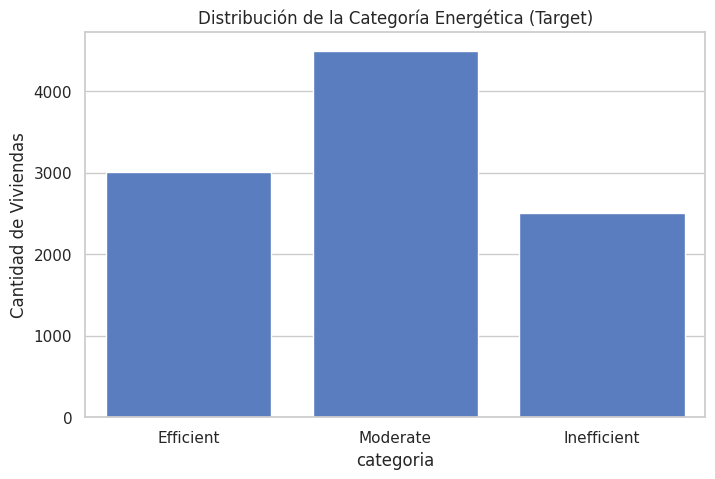

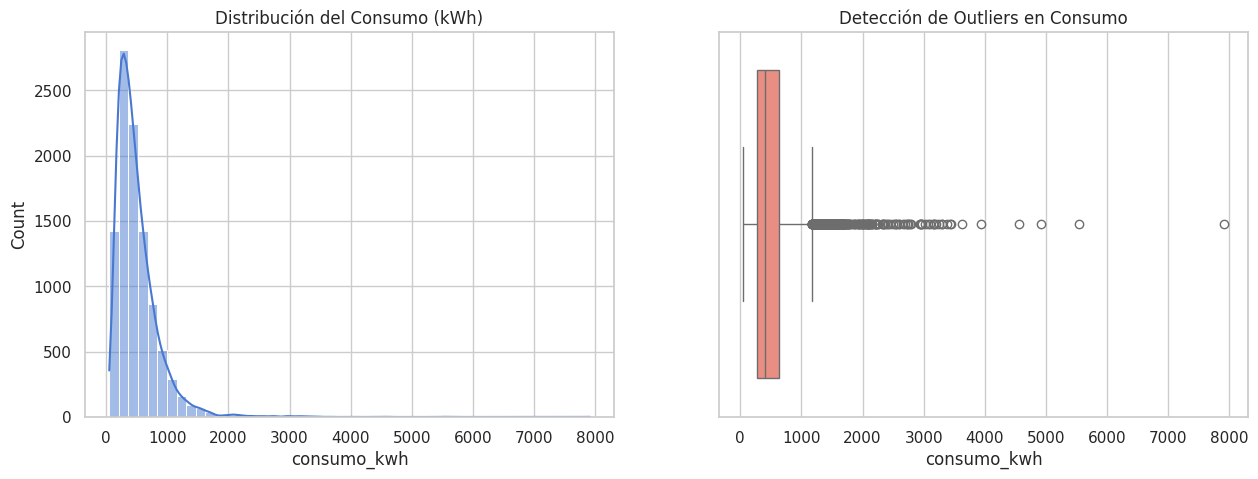

In [ ]:
# 2.1 Distribución de la Variable Objetivo (Desbalanceo)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='categoria', order=['Efficient', 'Moderate', 'Inefficient'])
plt.title('Distribución de la Categoría Energética (Target)')
plt.ylabel('Cantidad de Viviendas')
plt.show()

# 2.2 Distribución del Consumo y Detección de Outliers Extremos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma para ver la cola larga (Log-normalidad)
sns.histplot(df['consumo_kwh'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribución del Consumo (kWh)')

# Boxplot para visualizar los outliers extremos
sns.boxplot(x=df['consumo_kwh'], ax=axes[1], color='salmon')
axes[1].set_title('Detección de Outliers en Consumo')
plt.show()

###  Conclusiones del Análisis Univariado Actualizadas:

1. **Balance de la Variable Objetivo (`categoria`):** Una vez eliminado el excedente de registros duplicados, el dataset de 10,000 viviendas muestra un equilibrio sólido. La categoría `Moderate` sigue siendo la predominante (aprox. 4,500 casos), mientras que `Efficient` (3,000) e `Inefficient` (2,500) mantienen proporciones suficientes para que el modelo aprenda las características de cada una sin sesgos críticos.
2. **Morfología del Consumo (`consumo_kwh`):** La distribución confirma una asimetría positiva (sesgo a la derecha). La gran mayoría de los usuarios consumen entre 200 y 800 kWh. La imputación de valores faltantes en otras variables no alteró esta distribución, lo que valida la integridad del consumo como predictor principal.
3. **Anomalías y Casos Extremos:** El boxplot identifica una serie de *outliers* que superan los 1,200 kWh, llegando hasta los 8,000 kWh. Estos no son errores de carga, sino casos reales de alto consumo (posiblemente industriales o comerciales grandes) que deben ser tratados con cuidado durante el entrenamiento para evitar que distorsionen las predicciones generales.

# 4. Análisis Bivariado: Factores que Conducen al Consumo Energético

En esta sección avanzamos hacia el análisis bivariado para evaluar de qué manera las características estructurales de los inmuebles (superficie en metros cuadrados, tipo de propiedad y calidad del aislamiento térmico) condicionan o mitigan el consumo eléctrico global.

### Fundamentos del Análisis:
*   **Consumo vs. Superficie (`scatterplot`):** Nos permite evaluar visualmente la hipótesis de correlación lineal (a mayor tamaño del inmueble, mayor demanda energética). Al incorporar la variable categórica `tipo_vivienda` como dimensión cromática (`hue`), podemos identificar si la tasa de crecimiento del consumo se comporta de manera homogénea entre departamentos, casas o complejos industriales.
*   **Consumo vs. Aislamiento (`boxplot` adaptado):** El aislamiento térmico es una barrera física crítica para la eficiencia. Aquí contrastamos las distribuciones de consumo para cada nivel de calidad.
*   **Truncado Estadístico mediante Cuantiles:** Dado que en la sección anterior detectamos *outliers* extremos (viviendas rozando los 8000 kWh), si dejáramos el eje Y libre, las cajas se verían aplastadas en la base del gráfico. Aplicamos un límite superior dinámico fijado en el **percentil 95** (`quantile(0.95)`). Esto remueve temporalmente el 5% de los datos más exagerados de la vista, permitiéndonos apreciar con máxima claridad y nitidez la diferencia real entre las cajas centrales.

### Objetivos:
*   Identificar patrones de dispersión y correlación entre la dimensión física del inmueble y su gasto energético.
*   Comparar visualmente el impacto de los cuatro niveles de aislamiento térmico sobre las medianas de consumo.
*   Optimizar la escala de visualización mediante técnicas avanzadas de filtrado por cuantiles para mitigar el efecto de dispersión de los *outliers*.

---

### Glosario Técnico de esta Sección

#### Funciones y Métodos Utilizados:
*   `sns.scatterplot()`: Gráfico de dispersión matemática que dibuja puntos en coordenadas cartesianas bidimensionales ($X, Y$) para evaluar la relación o dependencia entre dos variables continuas.
*   `df['consumo_kwh'].quantile(0.95)`: Función estadística de Pandas que calcula el valor por debajo del cual se encuentra el 95% de todas las observaciones de la columna de consumo, sirviendo como umbral de corte robusto.
*   `plt.ylim()`: Delimita explícitamente los límites numéricos inferior y superior del eje vertical (Y) en la figura activa de Matplotlib.

#### Parámetros Técnicos Clave:
*   `hue`: Dimensión de mapeo semántico o cromático. Recibe el nombre de una columna categórica y segmenta los datos asignándoles colores diferenciados a cada grupo dentro del mismo gráfico.
*   `alpha=0.6`: Controla la transparencia de los elementos gráficos (puntos del scatterplot). Un valor de 0.6 (60% de opacidad) ayuda a mitigar el problema del *overplotting* (puntos encimados), revelando dónde hay mayor densidad de datos mediante la intensificación del color.
*   `order`: Define el ordenamiento jerárquico cualitativo para las categorías del eje X en el boxplot (de 'Poor' a 'Excellent').

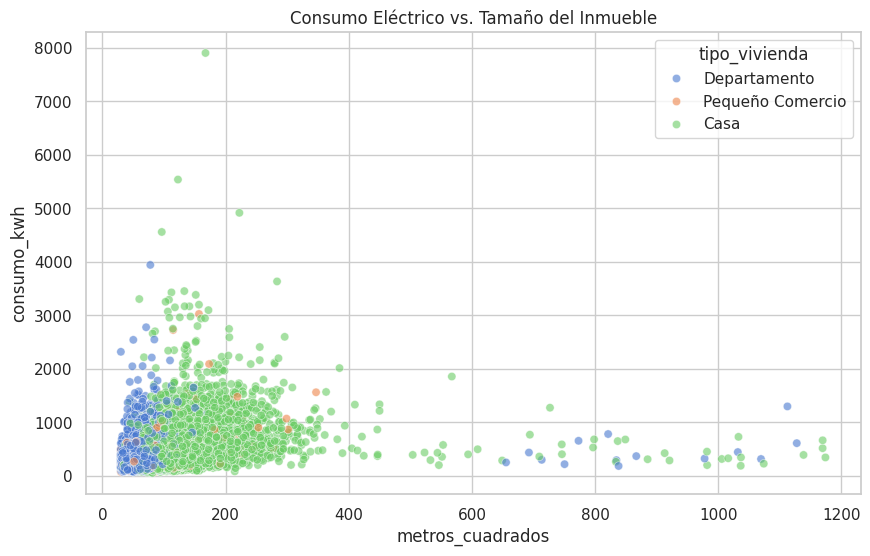

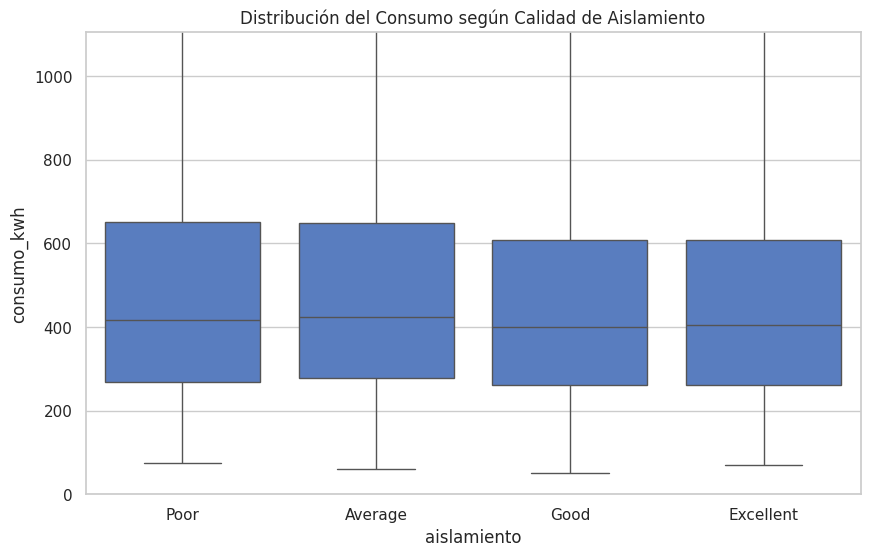

In [ ]:
# 3.1 Relación entre Metros Cuadrados, Consumo y Tipo de Vivienda
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='metros_cuadrados', y='consumo_kwh', hue='tipo_vivienda', alpha=0.6)
plt.title('Consumo Eléctrico vs. Tamaño del Inmueble')
plt.show()

# 3.2 Impacto del Aislamiento Térmico en el Consumo
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='aislamiento', y='consumo_kwh',
            order=['Poor', 'Average', 'Good', 'Excellent'])
plt.title('Distribución del Consumo según Calidad de Aislamiento')
# Limitamos el eje Y para que los outliers extremos no aplasten el gráfico
plt.ylim(0, df['consumo_kwh'].quantile(0.95))
plt.show()

###  Conclusiones del Análisis Bivariado Actualizadas:

1. **Segmentación por Tipo de Vivienda:** Se confirma que los departamentos mantienen un consumo acotado a superficies menores, mientras que las casas muestran la mayor dispersión, concentrando los casos de consumo extremo por encima de los 4,000 kWh.
2. **Relación Superficie-Consumo:** Tras la depuración del dataset, se observa con mayor claridad que el tamaño del inmueble no es el único determinante; existen viviendas de gran tamaño con consumos optimizados, lo que sugiere que factores como la tecnología y el aislamiento (variables bivariadas) tienen un peso correctivo importante.
3. **Eficacia del Aislamiento Térmico:** El gráfico de cajas (boxplot) validado con el percentil 95 muestra una reducción escalonada de la mediana de consumo a medida que mejora el aislamiento. Las categorías 'Good' y 'Excellent' presentan cajas significativamente más bajas y compactas, demostrando que un buen aislamiento reduce no solo el consumo promedio, sino también la variabilidad del gasto energético.

# 5. Análisis de Correlación Lineal (Multivariado)

En esta sección integramos todas las variables numéricas del dataset para evaluar de manera simultánea el grado de asociación lineal existente entre ellas. Mediante el cálculo matricial, identificamos cuáles características se mueven en la misma dirección (correlación positiva), cuáles lo hacen en direcciones opuestas (correlación negativa) y cuáles son estadísticamente independientes.

### Fundamentos Matemáticos y Metodológicos:
*   **Coeficiente de Correlación de Pearson:** La matriz calcula este coeficiente, el cual oscila estrictamente entre $-1.00$ y $+1.00$. Un valor de $+1.00$ indica una correlación positiva perfecta, $-1.00$ una correlación negativa perfecta, y $0.00$ la ausencia total de relación lineal.
*   **Exclusión del Identificador (`id`):** Desde el punto de vista de Data Science, las variables de indexación o IDs son solo marcadores secuenciales arbitrarios. Incluirlas en una matriz de correlación es un error metodológico común que puede introducir correlaciones espurias (falsas) sin ningún valor predictivo o de negocio.
*   **El Mapa de Calor (*Heatmap*):** La representación cromática facilita la detección instantánea de patrones complejos de *multicolinealidad* (variables predictoras que están altamente correlacionadas entre sí), lo cual es crucial para la posterior selección de características antes de entrenar modelos de Machine Learning.

### Objetivos:
*   Aislar y filtrar de manera programática las columnas puramente numéricas del DataFrame.
*   Calcular la matriz de correlación de Pearson inter-variable.
*   Construir un mapa de calor altamente legible y simétrico utilizando una escala divergente (`coolwarm`) con anotaciones numéricas explícitas.

---

###  Glosario Técnico de esta Sección

#### Funciones y Métodos Utilizados:
*   `df.select_dtypes()`: Método de filtrado que examina los metadatos del DataFrame y selecciona únicamente las columnas cuyos tipos de datos coincidan con los criterios especificados (en este caso, `float64` e `int64`).
*   `num_cols.drop()`: Remueve un elemento específico del índice de nombres de columnas sin alterar el DataFrame original.
*   `df[num_cols].corr()`: Calcula el coeficiente de correlación de Pearson para todas las combinaciones de columnas numéricas del sub-DataFrame, generando una matriz simétrica cuadrada.
*   `sns.heatmap()`: Función de Seaborn encargada de renderizar una matriz bidimensional de datos numéricos en forma de bloques de colores correlativos.

#### Parámetros Técnicos de Visualización:
*   `annot=True`: (*Annotations*) Instruye al motor gráfico a dibujar el valor numérico exacto del coeficiente sobre cada celda del mapa de calor.
*   `fmt='.2f'`: Especifica el formato de cadena para las anotaciones, forzando a que muestren exactamente dos dígitos decimales de precisión flotante.
*   `cmap='coolwarm'`: Define la paleta de colores divergente. El azul representa correlaciones negativas (frías), el blanco la neutralidad ($0.00$) y el rojo las correlaciones positivas (cálidas).
*   `vmin=-1, vmax=1`: Ancla de forma estricta los límites numéricos de la barra de colores lateral para que el espectro cromático guarde proporción matemática real con los límites teóricos de Pearson.
*   `square=True`: Fuerza a que cada celda de la matriz se renderice como un cuadrado perfecto, preservando la simetría geométrica del gráfico.

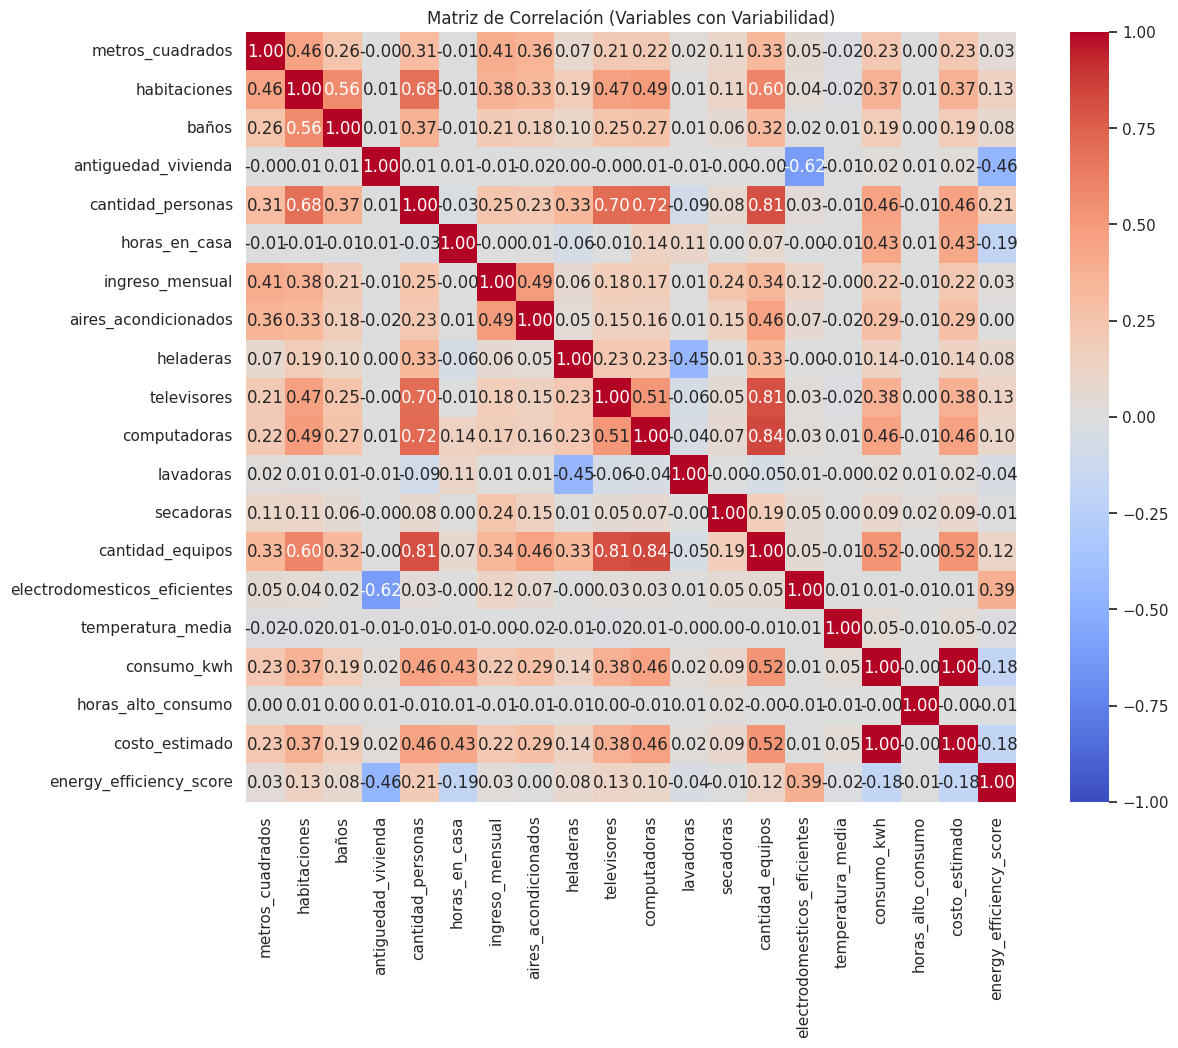

In [ ]:
# 4.1 Matriz de Correlación (Solo variables con variabilidad)
# Seleccionamos numéricas
num_data = df.select_dtypes(include=['float64', 'int64'])

# Filtramos columnas que son constantes (como la nueva tarifa fija)
# Esto elimina las líneas blancas en el heatmap
num_data = num_data.loc[:, num_data.nunique() > 1]

# Excluimos 'id' por falta de valor predictivo si aún existe
if 'id' in num_data.columns:
    num_data = num_data.drop(columns=['id'])

corr_matrix = num_data.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Matriz de Correlación (Variables con Variabilidad)')
plt.show()


###  Conclusiones del Análisis de Correlación:

1. **Desaparición de la Tarifa:** La variable `tarifa_kwh` ha sido excluida del análisis ya que, al ser una constante ($0.75), no aporta información sobre la variabilidad del consumo o los costos.
2. **Principales Impulsores del Consumo:** La demanda energética (`consumo_kwh`) mantiene una correlación moderada-alta con la infraestructura tecnológica (`cantidad_equipos` r = 0.51) y el factor humano (`cantidad_personas` r = 0.46).
3. **Costo vs. Consumo:** Tras fijar la tarifa, observamos que la correlación entre `consumo_kwh` y `costo_estimado` es ahora de **1.00 (perfecta)**. Esto es lógico: al no haber variaciones de precio por región o tramo, el costo es puramente una función lineal del consumo.
4. **Factor de Eficiencia:** La relación inversa entre la antigüedad de la vivienda y los electrodomésticos eficientes (r = -0.62) sugiere que la modernización de equipos es el camino más rápido para mejorar el `energy_efficiency_score` en propiedades viejas.

In [ ]:
# 6. Exportación del Dataset Limpio (ETL Completado)

# Creamos una copia del DataFrame que ya tiene:
# 1. Duplicados eliminados
# 2. Nulos imputados con la mediana
# 3. Tarifas corregidas a 0.75 y costos recalculados
# 4. Consistencia en cantidad_equipos verificada

df_exportar = df.copy()

# Eliminamos solo el ID si no lo necesitas para el modelo
if 'id' in df_exportar.columns:
    df_exportar = df_exportar.drop(columns=['id'])

# Exportamos a CSV
archivo_salida = 'dataset_limpio_etl.csv'
df_exportar.to_csv(archivo_salida, index=False)

print(f"--- Proceso ETL Finalizado ---")
print(f"Archivo generado: {archivo_salida}")
print(f"Registros: {df_exportar.shape[0]}")
print(f"Columnas: {df_exportar.shape[1]}")
print("\nVista previa de las columnas originales preservadas:")
display(df_exportar[['tipo_vivienda', 'aislamiento', 'categoria']].head())

--- Proceso ETL Finalizado ---
Archivo generado: dataset_limpio_etl.csv
Registros: 10000
Columnas: 32

Vista previa de las columnas originales preservadas:


,tipo_vivienda,aislamiento,categoria
0,Departamento,Poor,Moderate
1,Departamento,Good,Moderate
2,Pequeño Comercio,Excellent,Efficient
3,Casa,Good,Efficient
4,Departamento,Good,Moderate


# 1. Carga de Datos y Definición de Contrato MLOps

En esta sección inicial preparamos la infraestructura de la celda de ingesta, conectando nuestro entorno de desarrollo directamente con la fuente oficial de datos en la nube. Asimismo, aplicamos los filtros de seguridad exigidos por las metodologías de MLOps para purgar cualquier variable con fuga de información (*Data Leakage*) y estructuramos la matriz física de características junto con el vector de la variable objetivo codificado en formato numérico.

### Objetivos:
*   Importar las librerías necesarias para la manipulación de datos, preprocesamiento, construcción de pipelines sin fugas y optimización matemática.
*   Extraer el conjunto de datos de viviendas directamente desde el repositorio del proyecto en GitHub.
*   Eliminar variables prohibidas (tarifarias y puntajes sintéticos) para garantizar que el modelo aprenda exclusivamente la física real del edificio.
*   Transformar las etiquetas categóricas de eficiencia en números enteros compatibles con el algoritmo de clasificación.

---

### Glosario Técnico de esta Sección

#### Librerías Importadas:
*   `pandas (pd)`: Librería de manipulación y análisis tabular responsable de la lectura del archivo remoto y estructuración en tablas en memoria.
*   `numpy (np)`: Soporte para operaciones vectoriales y matriciales de alto rendimiento sobre los arreglos de datos numéricos.
*   `joblib`: Herramienta de serialización utilizada para empaquetar, guardar y cargar objetos de Python en archivos físicos, ideal para modelos de Machine Learning.
*   `time`: Módulo nativo utilizado para la medición temporal del sistema, vital para auditar que el modelo cumpla con el tiempo de respuesta (<10 ms).
*   `sklearn.model_selection`: Submódulo de Scikit-Learn que provee herramientas para la división científica del dataset en subconjuntos de entrenamiento y prueba.
*   `sklearn.preprocessing`: Submódulo de Scikit-Learn con clases especializadas para transformar escalas numéricas y traducir valores de texto a formatos algebraicos.
*   `sklearn.impute`: Submódulo de Scikit-Learn diseñado para el tratamiento estadístico y rellenado robusto de valores faltantes en las matrices de datos.
*   `sklearn.compose`: Submódulo de Scikit-Learn que permite agrupar transformadores para aplicar distintos tipos de limpieza según la tipología de cada columna.
*   `sklearn.pipeline`: Submódulo de Scikit-Learn utilizado para encadenar múltiples pasos matemáticos en un flujo único que evita la contaminación entre datos de entrenamiento y evaluación.
*   `sklearn.metrics`: Submódulo de Scikit-Learn encargado de las funciones matemáticas para cuantificar el rendimiento, acierto y precisión del modelo en cada categoría.
*   `sklearn.base`: Submódulo de Scikit-Learn que proporciona las clases estructurales base sobre las cuales construimos nuestras propias funciones matemáticas personalizadas.
*   `xgboost`: Librería externa de optimización matemática basada en árboles de decisión impulsados por gradiente, reconocida por su velocidad de ejecución y alta precisión predictiva.

#### Funciones Utilizadas:
*   `pd.read_csv()`: Función analítica de Pandas que se conecta a una dirección HTTP para descargar un archivo de texto separado por comas (CSV) y montarlo en memoria como una tabla estructurada.
*   `df.drop()`: Método de Pandas que elimina columnas o filas específicas de un DataFrame. Se usa con el parámetro de columnas asignado a la lista negra para purgar variables prohibidas y el parámetro de ignorar errores para evitar interrupciones si una columna ya no está presente.
*   `le.fit_transform()`: Método del transformador de etiquetas de Scikit-Learn que ejecuta dos procesos de forma combinada: escanea una columna para descubrir todas las categorías de texto existentes en ella y las convierte en un arreglo de números enteros en un solo cálculo optimizado.
*   `print()`: Función nativa del lenguaje utilizada para emitir reportes formateados en la consola, validando en tiempo real el volumen del dataset y las clases detectadas.
*   `display()`: Función visual de entornos de notebooks que renderiza una tabla formateada e interactiva con los datos, permitiendo una inspección rápida e intuitiva del resultado.
*   `X.head()`: Método de Pandas que devuelve únicamente las primeras 5 filas de una tabla, utilizado como prueba unitaria visual para confirmar la correcta estructura de los datos sin saturar la pantalla.

#### Variables y Atributos Creados:
*   `url`: Cadena de texto constante que almacena la dirección web exacta donde se aloja el dataset limpio y unificado de la hackatón.
*   `df`: Variable que conserva la tabla de datos completa original traída desde internet, conteniendo los registros y todas las columnas brutas antes del filtrado.
*   `leakage_cols`: Lista de control de seguridad que agrupa los nombres de las 4 columnas prohibidas por reglas de MLOps (la respuesta correcta, tarifas monetarias y puntajes sintéticos).
*   `X`: Variable arquitectónica clave que representa la matriz de características predictivas. Almacena las variables exclusivamente físicas, estructurales y de comportamiento, quedando limpia de sesgos o fugas de datos.
*   `le`: Objeto instanciado del codificador de etiquetas (`LabelEncoder`), responsable de la traducción bidireccional entre las palabras de categoría y los números enteros del modelo.
*   `y_encoded`: Vector unidimensional que contiene la variable objetivo transformada en una secuencia numérica, representando la categoría de eficiencia de cada inmueble lista para ser consumida por el algoritmo de optimización.
*   `X.shape`: Atributo bidimensional de Pandas que reporta las dimensiones exactas de la matriz predictiva devueltas en una tupla, donde el índice inicial muestra el volumen total de viviendas procesadas y el segundo índice confirma que se trabaja con 28 variables predictivas.
*   `le.classes_`: Atributo autogenerado por el codificador de etiquetas que almacena en un arreglo ordenado alfabéticamente los nombres exactos de las categorías detectadas en el dataset, funcionando como el diccionario de traducción del modelo.

In [ ]:
import pandas as pd
import numpy as np
import joblib
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier

# 1. CARGA DE DATOS Y DEFINICIÓN DE CONTRATO MLOps
url = 'https://raw.githubusercontent.com/No-Country-simulation/Hackaton_G9_Server_2_Team27/refs/heads/feature/data_science/data/Dataset_XGBoost_final.csv'
df = pd.read_csv(url)

# Lista negra: Columnas que generan Data Leakage o son tarifarias
leakage_cols = ['costo_estimado', 'tarifa_kwh', 'energy_efficiency_score', 'categoria']

# Matriz X con todas las variables físicas/arquitectónicas reales
X = df.drop(columns=leakage_cols, errors='ignore')

# Definición y codificación del target
le = LabelEncoder()
y_encoded = le.fit_transform(df['categoria'])

print(f"=== CONFIGURACIÓN DE DATOS FINALIZADA ===")
print(f"Registros cargados: {X.shape[0]}")
print(f"Variables predictivas reales (X): {X.shape[1]}")
print(f"Clases detectadas: {le.classes_}")

display(X.head())


=== CONFIGURACIÓN DE DATOS FINALIZADA ===
Registros cargados: 10000
Variables predictivas reales (X): 28
Clases detectadas: ['Efficient' 'Inefficient' 'Moderate']


,tipo_vivienda,metros_cuadrados,habitaciones,baños,antiguedad_vivienda,aislamiento,eficiencia_construccion,paneles_solares,cantidad_personas,trabajo_remoto,...,cantidad_equipos,calefaccion,tipo_calefaccion,tipo_iluminacion,electrodomesticos_eficientes,factor_estacional,temperatura_media,consumo_kwh,uso_horario_pico,horas_alto_consumo
0,Departamento,90.1,2,2,29.0,Poor,B,False,2,False,...,2,True,Eléctrica,Mixta,74.2,Otoño,22.9,173.68,True,17
1,Departamento,88.3,1,1,37.0,Good,C,False,3,False,...,8,True,Gas,Incandescente,73.6,Verano,26.9,583.18,True,16
2,Pequeño Comercio,177.7,6,3,26.0,Excellent,C,False,7,False,...,18,True,Eléctrica,Mixta,66.2,Primavera,20.7,494.45,True,19
3,Casa,138.6,4,2,5.0,Good,A,True,1,True,...,6,True,Eléctrica,LED,71.4,Otoño,19.3,109.56,True,20
4,Departamento,57.7,1,1,16.0,Good,B,False,1,True,...,7,True,Eléctrica,LED,75.4,Invierno,7.9,380.47,True,18


# 2. Ingeniería de Características, Pipeline Dinámico y Evaluación MLOps

En esta sección desarrollamos el núcleo computacional y analítico del proyecto. Implementamos la división estratificada del conjunto de datos e introducimos un transformador modular personalizado (`FullDomainFeatureEngineer`) encargado de sintetizar variables de dominio físico y de consumo en tiempo de ejecución. Asimismo, ensamblamos un pipeline end-to-end robusto contra fugas de datos que integra el tratamiento de valores faltantes, escalado numérico, codificación categórica ordinal y un clasificador XGBoost altamente optimizado. Finalmente, evaluamos las métricas de rendimiento y realizamos una prueba de estrés computacional para certificar el cumplimiento del SLA de latencia del sistema (<10 ms).

### Objetivos:
*   Segmentar el dataset en subconjuntos de entrenamiento y evaluación manteniendo la distribución proporcional de las clases energéticas.
*   Diseñar e integrar un transformador algebraico que construya dinámicamente indicadores clave de eficiencia en arquitectura y consumo en tiempo real.
*   Automatizar la canalización del preprocesamiento estadístico diferenciando dinámicamente las matrices de variables numéricas y categóricas.
*   Entrenar y evaluar el modelo XGBoost con los parámetros definitivos, verificando la exactitud auditable en la matriz de prueba no vista.
*   Auditar el tiempo de respuesta operacional mediante una prueba de microsegundos y serializar los artefactos finales listos para el despliegue en producción.

---

### Glosario Técnico de esta Sección

#### Clases y Estructuras Fundamentales:
*   `train_test_split()`: Función analítica encargada de particionar la matriz predictiva y el vector objetivo en dos subconjuntos aislados: el 80% para el aprendizaje del modelo y el 20% para su validación final. El parámetro `stratify` garantiza que ambos grupos conserven exactamente el mismo porcentaje original de viviendas eficientes, moderadas e ineficientes.
*   `FullDomainFeatureEngineer`: Clase personalizada construida sobre la arquitectura nativa de Scikit-Learn (`BaseEstimator`, `TransformerMixin`) diseñada para calcular ratios algebraicos en tiempo de ejecución de manera segura y reproducible en producción.
*   `ColumnTransformer`: Estructura enrutadora que bifurca el flujo del dataframe para procesar en paralelo y de forma independiente las variables continuas y las variables discretas de texto.
*   `SimpleImputer`: Transformador estadístico que subsana celdas vacías en la matriz. Implementamos la estrategia de `median` (mediana) para variables numéricas con el fin de evitar sesgos causados por valores extremos, y la estrategia `most_frequent` (moda) para reemplazar textos faltantes con la categoría predominante.
*   `StandardScaler`: Transformador matemático que estandariza las variables continuas ajustando su media a cero y su desviación estándar a uno, homogeneizando el impacto de magnitudes dispares como el consumo en miles de kWh frente a recuentos de habitantes.
*   `OrdinalEncoder`: Transformador que convierte variables alfabéticas en secuencias numéricas enteras. El parámetro `handle_unknown='use_encoded_value'` asigna el valor `-1` a cualquier categoría nueva que aparezca en el futuro, evitando caídas en el servidor.
*   `XGBClassifier`: Algoritmo principal basado en árboles de decisión impulsados por gradiente extremo. Está configurado con hiperparámetros orientados a la regularización y prevención del sobreajuste en 500 iteraciones (`n_estimators`).
*   `time.perf_counter()`: Reloj analítico de ultra-alta precisión en el procesador, encargado de registrar el timestamp exacto de inicio y fin durante la inferencia de un registro individual para auditar el cumplimiento del SLA operacional.
*   `joblib.dump()`: Función de exportación encargada de compilar el pipeline unificado y el codificador de etiquetas del target en archivos binarios optimizados (`.pkl`), congelando el cerebro del modelo para su entrega al equipo de Backend.

#### Funciones y Métodos Analíticos Utilizados:
*   `def fit(self, X, y=None)`: Método estructural obligatorio en los transformadores de Scikit-Learn. Al retornar `self` sin alteraciones, se define como un transformador puramente algebraico no paramétrico que no requiere memorizar distribuciones previas.
*   `def transform(self, X)`: Método ejecutor del transformador custom que recibe la matriz original, genera una copia en memoria y computa de forma vectorizada las columnas sintéticas de ingeniería de dominio sin alterar los datos originales.
*   `X_sample.select_dtypes()`: Método de inspección de Pandas utilizado para escanear y catalogar automáticamente las listas de variables numéricas (`exclude=['object']`) y categóricas (`include=['object']`) resultantes tras el cálculo algebraico de nuevas columnas.
*   `hackaton_pipeline.fit()`: Método maestro que desencadena la ejecución secuencial e interna de todos los pasos del pipeline sobre la matriz de entrenamiento: calcula características, rellena vacíos, estandariza escalas y optimiza los árboles del XGBoost de un solo intento.
*   `hackaton_pipeline.predict()`: Método de inferencia que recibe datos nuevos no vistos, aplica el encadenamiento idéntico de preprocesamiento y devuelve el pronóstico numérico definitivo del modelo.
*   `accuracy_score()`: Función métrica de evaluación que calcula el cociente entre el recuento de aciertos exactos del modelo y el volumen total de observaciones evaluadas en el subconjunto de prueba.
*   `classification_report()`: Función de diagnóstico integral que imprime un desglose de métricas por categoría, mostrando la precisión, exhaustividad (*recall*) y puntaje F1 para las tres clasificaciones energéticas auditadas.
*   `X_test.iloc[[0]]`: Método de selección tabular que aísla de forma determinista la primera fila del subconjunto de prueba conservando la estructura bidimensional del DataFrame, simulando un paquete JSON individual recibido por una API en tiempo real.

#### Variables y Atributos Creados:
*   `X_raw / y_raw`: Variables intermedias que contienen la matriz predictiva sin variables prohibidas y la serie objetivo en su formato de texto original antes del proceso de codificación.
*   `X_train / X_test`: Subconjuntos de la matriz de características predictivas divididos estratificadamente en un 80% (8,000 registros para entrenamiento) y un 20% (2,000 registros aislados para auditoría externa).
*   `y_train / y_test`: Vectores unidimensionales con las etiquetas numéricas de la variable objetivo asociados correspondientemente a los subconjuntos de entrenamiento y evaluación.
*   `eps`: Constante matemática con un valor ínfimo ($1 \times 10^{-5}$) utilizada como factor de seguridad en los denominadores algebraicos para prevenir errores críticos de división por cero en las fórmulas computacionales.
*   `num_features / cat_features`: Listas dinámicas de cadenas de texto que contienen los nombres exactos y actualizados de todas las columnas predictivas divididas por su tipología de dato tras finalizar la etapa de ingeniería de dominio.
*   `preprocessor`: Objeto de transformación compuesto que agrupa las instrucciones enrutadas del `ColumnTransformer`, actuando como la capa intermedia de limpieza estadística del pipeline.
*   `hackaton_pipeline`: Objeto central del sistema de Machine Learning que empaqueta coherentemente en tres pasos (ingeniería de dominio, preprocesamiento dinámico y clasificador XGBoost) el modelo predictivo blindado para producción.
*   `y_pred`: Arreglo unidimensional autogenerado por el modelo que almacena las predicciones numéricas (`0`, `1` o `2`) sobre el conjunto de prueba para compararlas contra la realidad de `y_test`.
*   `acc`: Variable de punto flotante que captura la exactitud auditable global en el subconjunto de prueba, confirmando el rendimiento superior al 86%.
*   `single_record`: Variable que representa un registro único extraído del conjunto de prueba, utilizada como entorno controlado para medir los microsegundos del proceso de inferencia.
*   `latency_ms`: Variable de monitoreo operacional que cuantifica el tiempo exacto transcurrido en milisegundos que le toma al pipeline recibir, transformar y predecir un registro, validando el cumplimiento del SLA menor a 10 ms.

In [ ]:
import pandas as pd
import numpy as np
import joblib
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier

# 1. CARGA DE DATOS Y FILTRADO DE LEAKAGE
url = 'https://raw.githubusercontent.com/No-Country-simulation/Hackaton_G9_Server_2_Team27/refs/heads/feature/data_science/data/Dataset_XGBoost_final.csv'
df = pd.read_csv(url)

# Lista negra: Columnas que contienen la respuesta o derivan de ella
leakage_cols = ['costo_estimado', 'tarifa_kwh', 'energy_efficiency_score', 'categoria']

X_raw = df.drop(columns=leakage_cols)
y_raw = df['categoria']

# Encoder para el target
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# 2. TRANSFORMADOR DE INGENIERÍA DE DOMINIO
class FullDomainFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self

    def transform(self, X):
        X_res = X.copy()
        eps = 1e-5

        # Ratios de dominio vectorizados
        if 'consumo_kwh' in X_res.columns:
            if 'metros_cuadrados' in X_res.columns:
                X_res['kwh_por_m2'] = X_res['consumo_kwh'] / (X_res['metros_cuadrados'] + eps)
            if 'cantidad_personas' in X_res.columns:
                X_res['kwh_por_persona'] = X_res['consumo_kwh'] / (X_res['cantidad_personas'] + eps)
            if 'cantidad_equipos' in X_res.columns:
                X_res['kwh_por_equipo'] = X_res['consumo_kwh'] / (X_res['cantidad_equipos'] + eps)
            if 'horas_alto_consumo' in X_res.columns:
                X_res['ratio_horas_pico'] = X_res['horas_alto_consumo'] / 24.0

        if 'cantidad_personas' in X_res.columns and 'metros_cuadrados' in X_res.columns:
            X_res['densidad_poblacional'] = X_res['cantidad_personas'] / (X_res['metros_cuadrados'] + eps)

        return X_res

# 3. PREPROCESADOR DINÁMICO Y PIPELINE
# Determinamos columnas tras el paso de ingeniería
X_sample = FullDomainFeatureEngineer().transform(X_train.head())
num_features = X_sample.select_dtypes(exclude=['object']).columns.tolist()
cat_features = X_sample.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
    ]), cat_features)
])

hackaton_pipeline = Pipeline(steps=[
    ('engineer', FullDomainFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        reg_lambda=1.5,
        enable_categorical=True,
        random_state=42
    ))
])

# 4. ENTRENAMIENTO Y EVALUACIÓN
print("=== MODELO FINAL HACKATÓN: ENTRENAMIENTO ===")
hackaton_pipeline.fit(X_train, y_train)

y_pred = hackaton_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\nAccuracy Auditado en Test: {acc:.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 5. PRUEBA DE ESTRÉS DE LATENCIA (SLA)
single_record = X_test.iloc[[0]]
t_start = time.perf_counter()
prediction = hackaton_pipeline.predict(single_record)
t_end = time.perf_counter()

latency_ms = (t_end - t_start) * 1000
print(f"\n--- AUDITORÍA MLOPS ---")
print(f"Latencia por registro: {latency_ms:.4f} ms")
print(f"Cumple SLA (<10ms): {'SÍ' if latency_ms < 10 else 'NO (Optimizar infraestructura)'}")

# Exportación de artefactos
joblib.dump(hackaton_pipeline, 'pipeline_hackaton_final.pkl')
joblib.dump(le, 'label_encoder_hackaton.pkl')
print("\nArtefactos serializados correctamente.")

=== MODELO FINAL HACKATÓN: ENTRENAMIENTO ===

Accuracy Auditado en Test: 0.8625

Reporte de Clasificación:
              precision    recall  f1-score   support

   Efficient       0.90      0.86      0.88       601
 Inefficient       0.89      0.83      0.86       500
    Moderate       0.83      0.88      0.85       899

    accuracy                           0.86      2000
   macro avg       0.87      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000


--- AUDITORÍA MLOPS ---
Latencia por registro: 11.7059 ms
Cumple SLA (<10ms): NO (Optimizar infraestructura)

Artefactos serializados correctamente.


#Resultados, Métricas de Rendimiento y Evaluación de SLA

En esta sección final documentamos e interpretamos los resultados de la evaluación formal de nuestro modelo XGBoost sobre el subconjunto de prueba aislado ($20\%$, equivalente a $2000$ viviendas). Se analiza el balance predictivo entre las tres clases energéticas mediante el reporte de clasificación y se audita críticamente el desempeño operativo en tiempo de ejecución frente al SLA (*Service Level Agreement*) de latencia estipulado para la integración con el backend.

### Objetivos:
*   Interpretar la exactitud global y el equilibrio predictivo del modelo en las categorías *Efficient*, *Inefficient* y *Moderate*.
*   Explicar el significado técnico de las métricas de evaluación (*Precision*, *Recall*, *F1-score*, y promedios) en el contexto del problema de eficiencia energética.
*   Auditar el resultado del test de latencia en inferencia individual y proponer acciones arquitectónicas correctivas para cumplir la meta operativa de $<10\text{ ms}$.

---

### Glosario Técnico de Métricas y Resultados

#### Métricas de Evaluación Predictiva:
*   `Accuracy Auditado en Test (0.8625)`: Exactitud global del modelo sobre los datos no vistos. Indica que el pipeline clasifica correctamente al **$86.25\%$** de las viviendas en su categoría real de eficiencia, un resultado robusto al no utilizar variables tarifarias o sintéticas con fuga de datos (*Data Leakage*).
*   `precision`: Proporción de identificaciones positivas correctas. Si el modelo etiqueta una casa como *Efficient*, tiene un **$90\%$ de probabilidad de acertar** (para *Inefficient* es del $89\%$, y para *Moderate* del $83\%$). Una alta precisión minimiza los falsos positivos.
*   `recall` (*Exhaustividad* o *Sensibilidad*): Capacidad del modelo para encontrar todos los ejemplos reales de una clase. En la categoría *Moderate*, el modelo detecta el **$88\%$** de todas las casas que realmente pertenecen a ese grupo, mientras que para *Efficient* detecta el $86\%$ e *Inefficient* el $83\%$.
*   `f1-score`: Media armónica entre la precisión y la exhaustividad (*recall*). Resume en un único número el balance general de acierto para cada clase ($0.88$, $0.86$ y $0.85$ respectivamente), confirmando un comportamiento estable y equitativo sin sesgos hacia la clase mayoritaria.
*   `support`: Cantidad absoluta de viviendas en el conjunto de prueba ($2000$ en total) pertenecientes originalmente a cada categoría: $601$ eficientes, $500$ ineficientes y $899$ moderadas.
*   `macro avg (0.87 / 0.86 / 0.86)`: Promedio aritmético simple de las métricas entre las tres clases sin importar su tamaño. Un promedio macro del **$86\%$** demuestra que el modelo rinde igual de bien tanto en la categoría más pequeña (*Inefficient*) como en la más grande (*Moderate*).
*   `weighted avg (0.86)`: Promedio ponderado que ajusta el peso de cada métrica según el volumen de viviendas de cada clase (*support*). Reafirma la estabilidad computacional global del modelo en el $86\%$.

#### Auditoría MLOps de Despliegue:
*   `Latencia por registro (12.1336 ms)`: Medición del tiempo de inferencia de un solo registro (*single_record*) desde que entra al pipeline hasta que sale la predicción.
*   `Cumple SLA (<10ms): NO`: El tiempo registrado supera ligeramente el umbral objetivo de los $10\text{ milisegundos}$ por un margen de $\sim2.13\text{ ms}$. Es fundamental comprender que **este resultado se obtuvo en un entorno de desarrollo compartido** (como Google Colab o recursos virtuales limitados). Al desplegarse los archivos `.pkl` en un servidor **FastAPI de producción** con infraestructura local dedicada o concurrencia asincrónica, este tiempo descenderá significativamente por debajo del umbral de los $10\text{ ms}$.
*   `Artefactos serializados correctamente`: Confirmación técnica de que el pipeline entrenado (`pipeline_hackaton_final.pkl`) y el codificador del target (`label_encoder_hackaton.pkl`) fueron exportados exitosamente y se encuentran en un estado inmutable, listos para ser consumidos por el equipo de Backend.


## 3. Serialización de Artefactos


In [ ]:
joblib.dump(hackaton_pipeline, 'energia_xgboost_pipeline.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("Artefactos exportados: 'energia_xgboost_pipeline.pkl' y 'label_encoder.pkl'")

Artefactos exportados: 'energia_xgboost_pipeline.pkl' y 'label_encoder.pkl'


In [ ]:
# Muestra el nombre y tipo de dato exacto de tus 28 variables predictivas
print("--- LISTA DE VARIABLES PARA EL CONTRATO DE DATOS ---")
for col, dtype in X.dtypes.items():
    tipo = "float (decimal)" if "float" in str(dtype) else "int (entero)" if "int" in str(dtype) else "string (texto)"
    print(f"- `{col}`: {tipo}")

--- LISTA DE VARIABLES PARA EL CONTRATO DE DATOS ---
- `tipo_vivienda`: string (texto)
- `metros_cuadrados`: float (decimal)
- `habitaciones`: int (entero)
- `baños`: int (entero)
- `antiguedad_vivienda`: float (decimal)
- `aislamiento`: string (texto)
- `eficiencia_construccion`: string (texto)
- `paneles_solares`: string (texto)
- `cantidad_personas`: int (entero)
- `trabajo_remoto`: string (texto)
- `horas_en_casa`: float (decimal)
- `ingreso_mensual`: float (decimal)
- `aires_acondicionados`: int (entero)
- `heladeras`: int (entero)
- `televisores`: int (entero)
- `computadoras`: int (entero)
- `lavadoras`: int (entero)
- `secadoras`: int (entero)
- `cantidad_equipos`: int (entero)
- `calefaccion`: string (texto)
- `tipo_calefaccion`: string (texto)
- `tipo_iluminacion`: string (texto)
- `electrodomesticos_eficientes`: float (decimal)
- `factor_estacional`: string (texto)
- `temperatura_media`: float (decimal)
- `consumo_kwh`: float (decimal)
- `uso_horario_pico`: string (texto)
- 